# 02 — RFM Feature Engineering
Built from raw invoices (nothing pre-aggregated), as of the day after the last
transaction. Beyond classic R/F/M we add behavior features that separate a
strong project from a tutorial: **AvgOrderValue**, **InterPurchaseStd**
(regular vs sporadic buyers), **ProductDiversity**, **TenureDays**.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

rfm = pd.read_parquet("../data/processed/rfm_features.parquet")
print(rfm.shape)
rfm.describe()[["Recency", "Frequency", "Monetary", "AvgOrderValue",
                "InterPurchaseStd", "ProductDiversity"]].round(1)

(5852, 11)


,Recency,Frequency,Monetary,AvgOrderValue,InterPurchaseStd,ProductDiversity
count,5852.0,5852.0,5852.0,5852.0,3289.0,5852.0
mean,200.2,6.3,2979.2,391.0,57.7,82.2
min,1.0,1.0,3.0,3.0,0.0,1.0
25%,25.0,1.0,345.0,180.6,24.1,19.0
50%,95.0,3.0,880.4,283.7,45.5,45.0
75%,379.0,7.0,2289.3,418.0,77.4,103.0
max,739.0,373.0,608821.6,84236.2,308.5,2546.0
std,208.5,12.7,14605.0,1255.5,46.5,116.5


## Why the log-transform matters (heavy right skew)
Frequency and Monetary span 4 orders of magnitude — a few wholesale buyers
would dominate every Euclidean distance without it.

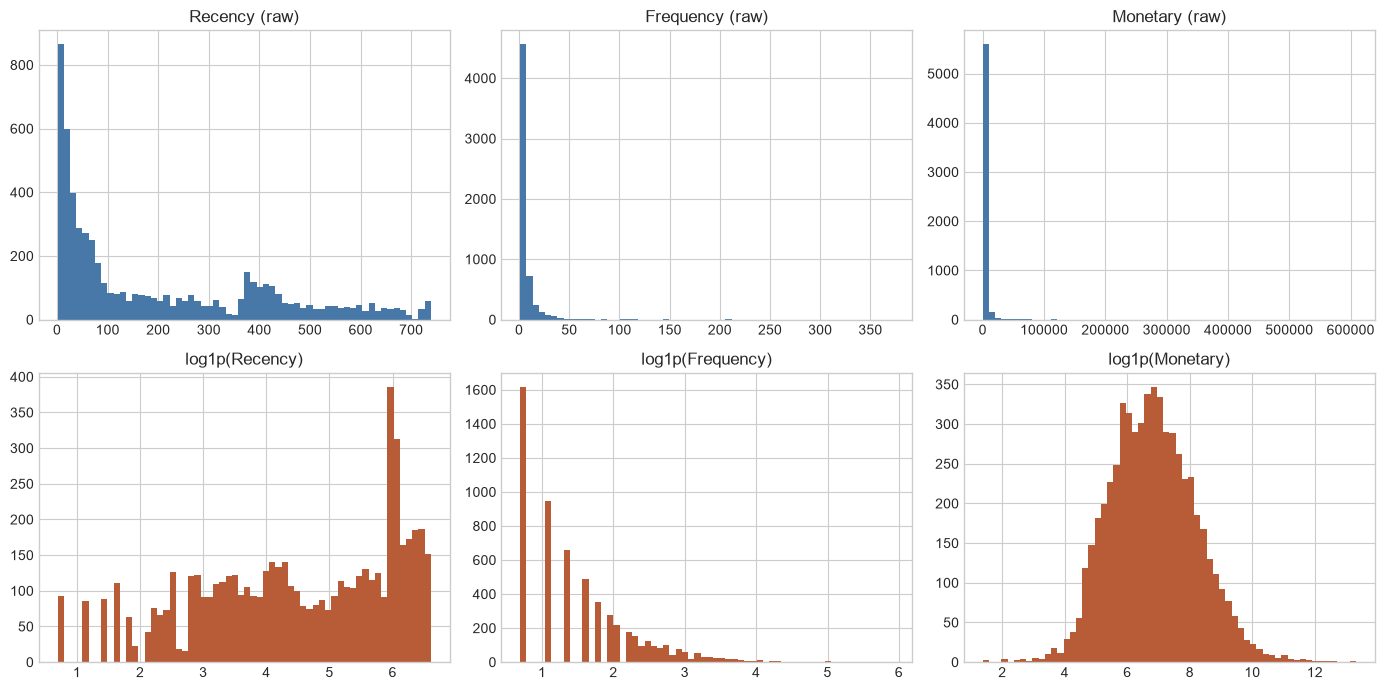

In [2]:
import numpy as np
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    axes[0, i].hist(rfm[col], bins=60, color="#4878A8")
    axes[0, i].set_title(f"{col} (raw)")
    axes[1, i].hist(np.log1p(rfm[col]), bins=60, color="#B85C38")
    axes[1, i].set_title(f"log1p({col})")
fig.tight_layout(); fig.savefig("figures/rfm_skew_logtransform.png", dpi=150)
plt.show()